# IrisDam-EcoScan: Urban Dynamics Analysis (2020 – 2024)  
## Notebook #1 – Pre-processing & Data Export

This notebook

1. Administrative Boundary Fetching:

Retrieves the official boundary for Amsterdam (Netherlands) to define the Region of Interest (ROI).

2. GEE Authentication:

Establishes a secure connection to the Google Earth Engine API to access global Sentinel-2 archives.

3. Summer Leaf-on Composites:

Filters imagery from April to August for each year (2020–2024). This period captures peak vegetation vigor, ensuring the most distinct spectral signatures.

Applies a custom Cloud Masking algorithm and a Median Reducer to generate seamless, cloud-free annual mosaics.

4. Feature Engineering & Export:

Spectral Bands: Exports B2 (Blue), B3 (Green), B4 (Red), B8 (NIR), B11 (SWIR1), and B12 (SWIR2).

Indices: Calculates and stacks NDVI (Vegetation), NDWI (Water), and NDBI (Built-up) as additional feature layers.

Outputs 9-band multi-spectral GeoTIFFs directly to Google Drive.

**Technical Significance:** These GeoTIFFs provide a consistent data foundation. By ensuring the same 9-band structure for every year, the notebook enables the unsupervised K-means and supervised Random Forest models to perform reliable spatiotemporal comparisons across the five-year study period.

# 1. Setup

In [ ]:
# Optional: Environmental Cost Tracking
import time
start_time = time.time()

In [ ]:
# Mount Google Drive (comment out if running locally)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# One-time package installs
!pip install -q -U geopandas shapely geemap earthengine-api rasterio requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.6/479.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
# Import Core Libraries
import time, datetime as dt, json, requests, ee, geemap, geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
# Define Direcories
ROOT   = Path('/content/drive/MyDrive/IrisDam-EcoScan/IrisDam-EcoScan/')
RAW    = ROOT / 'raw'
FIG    = ROOT / 'figures'
DATA   = ROOT / 'data'

for path in [RAW, FIG, DATA]:
    path.mkdir(parents=True, exist_ok=True)

### Authenticate with Google Earth Engine
This notebook uses the Google Earth Engine Python API to fetch and process Sentinel-2 satellite imagery.

**Before running this code**, you need to:
>
> 1. [Sign up for a Google Earth Engine account](https://signup.earthengine.google.com)
>
> 2. [Create a Google Cloud project](https://console.cloud.google.com)
>
> 3. [Enable the Earth Engine API for your project](https://console.developers.google.com/apis/api/earthengine.googleapis.com/overview)
>
> 4. [Register your project with Earth Engine (required for access](https://code.earthengine.google.com/register)

Once those steps are complete, you can run the cell below:

In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project='irisdam-ecoscan')    # Replace with your actual project ID if different

# 2. Define and download Area of Interest (AOI)

We request the NLD ADM2 (Dutch municipalities/Gemeenten) dataset from the Global Administrative Areas (GADM) database and extract the polygon whose shapeName equals Amsterdam. This serves as our spatial mask to clip all satellite imagery and focus our analysis on the city's urban and ecological boundaries.




In [ ]:
ISO, ADM = 'NLD', 'ADM2'
gb_url = f"https://www.geoboundaries.org/api/current/gbOpen/{ISO}/{ADM}"
meta   = requests.get(gb_url).json()
geojs  = requests.get(meta['gjDownloadURL']).json()

# Create GeoDataFrame
gdf = gpd.GeoDataFrame.from_features(geojs['features'])

# Assign CRS before transformation
gdf.set_crs('EPSG:4326', inplace=True)

# Filter Amsterdam and save
amsterdam_boundary = gdf[gdf['shapeName'] == 'Amsterdam'].to_crs('EPSG:4326')
ams_path = RAW / 'amsterdam_boundary.geojson'
amsterdam_boundary.to_file(ams_path, driver='GeoJSON')

print('Boundary saved →', ams_path.as_posix())
amsterdam_boundary[['shapeName', 'geometry']].head()

Boundary saved → /content/drive/MyDrive/IrisDam-EcoScan/IrisDam-EcoScan/raw/amsterdam_boundary.geojson


,shapeName,geometry
105,Amsterdam,"MULTIPOLYGON (((4.95524 52.27831, 4.95549 52.2..."


## Visual check of AOI

In [ ]:
map = geemap.Map(center=[52.3702, 4.8952], zoom=12)
map.addLayer(ee.FeatureCollection(json.loads(amsterdam_boundary.to_json())),
           {'color':'00FF00'}, 'Amsterdam Municipal Boundary ')
map

Map(center=[52.3702, 4.8952], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprig…

# 3. Data Collection from Earth Engine

In this section, we utilize the Earth Engine Python API to generate and export annual leaf-on composites (April–August) for the city of Amsterdam.

By focusing on the leaf-on season, we capture the period when vegetation is at its peak physiological activity. This maximizes the spectral contrast between different land cover types—such as the high NIR reflectance of the Amsterdam Forest (Amsterdamse Bos) versus the low reflectance of the canal network—thereby improving the accuracy of both unsupervised and supervised classification.

Processing Steps:
- Source Imagery: Fetch Sentinel-2 Level-2A surface reflectance data (10m spatial resolution).

- Atmospheric & Cloud Correction: Apply cloud and shadow masking using the Scene Classification Layer (SCL) to ensure a "clean" mosaic.

- Spectral Normalization: Normalize each band by clipping extreme values (2nd–98th percentile) to remove outliers.

- Rescaling: Rescale reflectance values to a 0–1 range on a per-image basis to prepare the data for machine learning.

- Feature Engineering (9 Layers):

  1. Include 6 core spectral bands (B2, B3, B4, B8, B11, B12).

  2. Calculate and add NDVI (Vegetation), NDWI (Water), and NDBI (Built-up) indices.

- Temporal Reduction: Compute median composites for each year (2020–2024) to create a single representative image per year.

- Cloud Export: Export the final 9-band GeoTIFFs to Google Drive (approx. 2–3 mins per year for the Amsterdam AOI).

These annual composites serve as the consistent data foundation for the entire IrisDam-EcoScan analytical pipeline.

## 3.1 Sentinel-2 annual composites for Amsterdam (2020-2024)


In [ ]:
# Define your bands of interest
BANDS = {
    "B2":  "blue",
    "B3":  "green",
    "B4":  "red",
    "B8":  "nir",
    "B11": "swir1",
    "B12": "swir2",
}

# Cloud and shadow masking using SCL band
def mask_s2_scl(img):
    scl = img.select("SCL")
    # 3 = Shadow, 8 = Medium Probability Cloud, 9 = High Probability Cloud, 10 = Cirrus Cloud
    mask = (scl.neq(3)
              .And(scl.neq(8))
              .And(scl.neq(9))
              .And(scl.neq(10)))
    return (img.updateMask(mask)
              .select(list(BANDS.keys()))
              .rename(list(BANDS.values())))

# Add NDVI and NDBI bands
def add_indices(img):
    ndvi = img.normalizedDifference(["nir", "red"]).rename("NDVI")
    ndbi = img.normalizedDifference(["swir1", "nir"]).rename("NDBI")
    ndwi = img.normalizedDifference(["green", "nir"]).rename("NDWI")
    return img.addBands([ndvi, ndwi, ndbi])

# Dynamically rescale each band to [0, 1] using 2nd–98th percentiles
def per_band_clip_and_rescale(img, lower=2, upper=98):
    def scale_band(band):
        pct = img.select(band).reduceRegion(
            reducer=ee.Reducer.percentile([lower, upper]),
            geometry=ee_ams, scale=10, bestEffort=True)
        lo = ee.Number(pct.get(f'{band}_p{lower}'))
        hi = ee.Number(pct.get(f'{band}_p{upper}'))
        return img.select(band).clamp(lo, hi).subtract(lo).divide(hi.subtract(lo))

    bands = list(BANDS.values())
    scaled = [scale_band(b) for b in bands]
    return ee.Image(scaled).rename(bands)

# Load AOI GeoJSON and convert to EE geometry
with open(RAW / "amsterdam_boundary.geojson") as f:
    ams_geojson = json.load(f)
ee_ams = geemap.geojson_to_ee(ams_geojson).geometry()

# Export normalized composites for each year
for yr in range(2020, 2025):
    print(f"Processing {yr}...")

    # Get clean image collection
    col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
             .filterBounds(ee_ams)
             .filterDate(f"{yr}-04-01", f"{yr}-08-31")
             .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 15))
             .map(mask_s2_scl)
             .map(lambda im: im.divide(10000))  # SR DN → reflectance
             .map(add_indices))

    # Generate composite
    comp = col.median().clip(ee_ams)
    comp = per_band_clip_and_rescale(comp)  # per-band dynamic rescaling
    comp = add_indices(comp).toFloat()

    # Export to Drive
    task = ee.batch.Export.image.toDrive(
        image=comp,
        description=f"S2_Amsterdam__{yr}",
        folder="IrisDam_EcoScan_Data",
        fileNamePrefix=f"s2_ams_composite_{yr}",
        region=ee_ams,
        scale=10,
        maxPixels=1e13
    )
    task.start()
    print(f"Export launched for {yr}")

# Print task list
print("\nActive Earth Engine tasks:")
for t in ee.batch.Task.list():
    if t.active():
        print("   ", t.id, t.status()["state"], t.config["description"])


Processing 2020...
Export launched for 2020
Processing 2021...
Export launched for 2021
Processing 2022...
Export launched for 2022
Processing 2023...
Export launched for 2023
Processing 2024...
Export launched for 2024

Active Earth Engine tasks:
    R6TVBZF5DXY6QLP36B4BSNPF READY S2_Amsterdam__2024
    UXNZ2ELS2F2OII4JSSLZUKZP READY S2_Amsterdam__2023
    7BMWIOQEPDQTD4UGABCCVYGC READY S2_Amsterdam__2022
    Y43YF2JS7TJOX3WXVN3ONLCW RUNNING S2_Amsterdam__2021
    QVPT73OXAHJHL446FIFFBWVS RUNNING S2_Amsterdam__2020


## 3.2 Preview the 2021 composite (RGB)

This cell demonstrates how to open a single exported GeoTIFF
and visualise an RGB thumbnail directly in Colab.  
(Adjust the year or the band stretch as you like.)

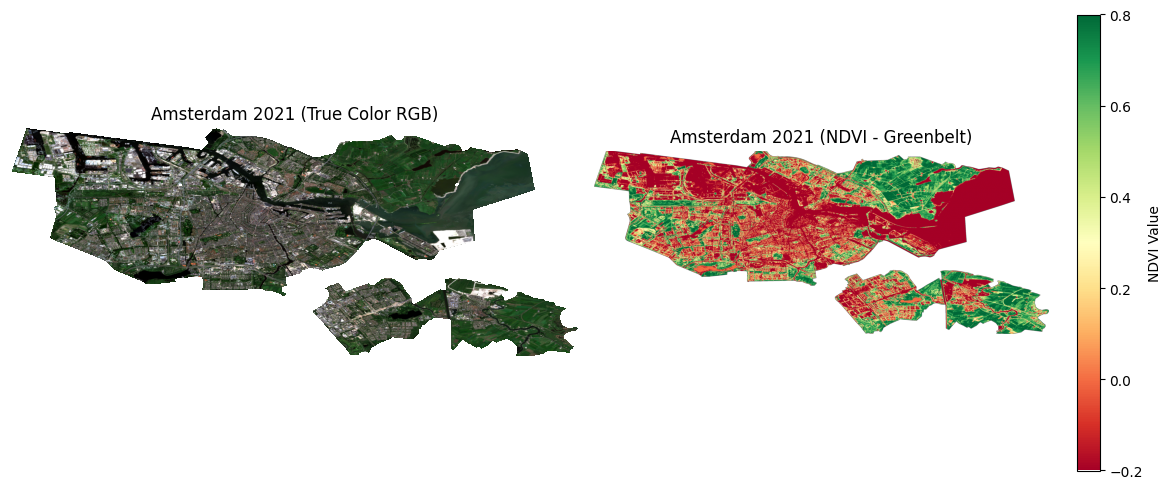

In [ ]:
# quicklook
import rasterio
import numpy as np
import matplotlib.pyplot as plt

tif_path = "/content/drive/MyDrive/IrisDam-EcoScan/IrisDam_EcoScan_Data/s2_ams_composite_2021.tif"   # adjust year if needed
with rasterio.open(tif_path) as src:
    rgb = src.read([3, 2, 1]).astype("float32")  # red, green, blue bands
    ndvi = src.read(7).astype("float32")
rgb = np.clip(rgb, 0, 1)  # no need to rescale again

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(np.moveaxis(rgb, 0, -1))
ax[0].set_title("Amsterdam 2021 (True Color RGB)")
ax[0].axis("off")
im = ax[1].imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
ax[1].set_title("Amsterdam 2021 (NDVI - Greenbelt)")
ax[1].axis("off")
plt.colorbar(im, ax=ax[1], label='NDVI Value', shrink=0.8)
plt.tight_layout()
plt.show()

# Enviromental Impact summary

In [ ]:
# End timer
end_time = time.time()
duration_sec = end_time - start_time
duration_hr = duration_sec / 3600

# Assumptions
CPU_POWER_W = 20
CARBON_INTENSITY = 0.325  # kg CO₂/kWh (Netherlands grid average)
ELECTRICITY_COST = 0.35   # €/kWh (Netherlands average)

# Energy used (kWh) = power (kW) × time (h)
energy_kwh = (CPU_POWER_W / 1000) * duration_hr
co2_kg = energy_kwh * CARBON_INTENSITY
cost_gbp = energy_kwh * ELECTRICITY_COST

# Print results
print(f"Runtime: {duration_hr:.4f} hours")
print(f"Energy used: {energy_kwh:.6f} kWh")
print(f"CO₂ emitted: {co2_kg:.6f} kg CO₂eq")
print(f"Estimated cost: €{cost_gbp:.4f}")

Runtime: 0.0254 hours
Energy used: 0.000507 kWh
CO₂ emitted: 0.000165 kg CO₂eq
Estimated cost: €0.0002
